In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/prince7489/phishing-email-detection-2026-dataset/phishing_email_detection_2026_dataset.csv


## Loading Dataset


In [2]:
df=pd.read_csv('/kaggle/input/datasets/prince7489/phishing-email-detection-2026-dataset/phishing_email_detection_2026_dataset.csv')

In [3]:
df.head()

,email_id,sender_email,subject,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing
0,1,harrisonsandra@paypal-alert.com,Meeting Reminder,0,1,2,0,227,0
1,2,randyharris@bankverify.net,Urgent Account Verification,1,1,9,7,59,1
2,3,adam13@outlook.com,Suspicious Login Attempt,1,1,8,10,67,1
3,4,kennethfisher@company-secure.com,Suspicious Login Attempt,0,1,9,8,102,1
4,5,wsandoval@paypal-alert.com,Your Password Will Expire,1,0,7,4,96,1


In [4]:
df.tail()

,email_id,sender_email,subject,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing
1495,1496,villabrian@gmail.com,Claim Your Reward Now,1,1,8,7,113,1
1496,1497,lharvey@gmail.com,Urgent Account Verification,1,0,8,5,50,1
1497,1498,xjennings@outlook.com,Suspicious Login Attempt,0,0,8,10,82,1
1498,1499,paulcobb@paypal-alert.com,Suspicious Login Attempt,1,0,7,9,36,1
1499,1500,kristen14@company-secure.com,Invoice Attached,0,1,4,0,161,0


In [5]:
df.describe

<bound method NDFrame.describe of       email_id                      sender_email                      subject  \
0            1   harrisonsandra@paypal-alert.com             Meeting Reminder   
1            2        randyharris@bankverify.net  Urgent Account Verification   
2            3                adam13@outlook.com     Suspicious Login Attempt   
3            4  kennethfisher@company-secure.com     Suspicious Login Attempt   
4            5        wsandoval@paypal-alert.com    Your Password Will Expire   
...        ...                               ...                          ...   
1495      1496              villabrian@gmail.com        Claim Your Reward Now   
1496      1497                 lharvey@gmail.com  Urgent Account Verification   
1497      1498             xjennings@outlook.com     Suspicious Login Attempt   
1498      1499         paulcobb@paypal-alert.com     Suspicious Login Attempt   
1499      1500      kristen14@company-secure.com             Invoice Attach

In [6]:
df.isnull().sum()

email_id              0
sender_email          0
subject               0
has_link              0
has_attachment        0
urgency_score         0
spelling_errors       0
email_length_words    0
is_phishing           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['email_id', 'sender_email', 'subject', 'has_link', 'has_attachment',
       'urgency_score', 'spelling_errors', 'email_length_words',
       'is_phishing'],
      dtype='object')

## EDA


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   email_id            1500 non-null   int64 
 1   sender_email        1500 non-null   object
 2   subject             1500 non-null   object
 3   has_link            1500 non-null   int64 
 4   has_attachment      1500 non-null   int64 
 5   urgency_score       1500 non-null   int64 
 6   spelling_errors     1500 non-null   int64 
 7   email_length_words  1500 non-null   int64 
 8   is_phishing         1500 non-null   int64 
dtypes: int64(7), object(2)
memory usage: 105.6+ KB
None
          email_id     has_link  has_attachment  urgency_score  \
count  1500.000000  1500.000000     1500.000000    1500.000000   
mean    750.500000     0.629333        0.512667       5.722667   
std     433.157015     0.483144        0.500006       3.002182   
min       1.000000     0.000000        0.0000

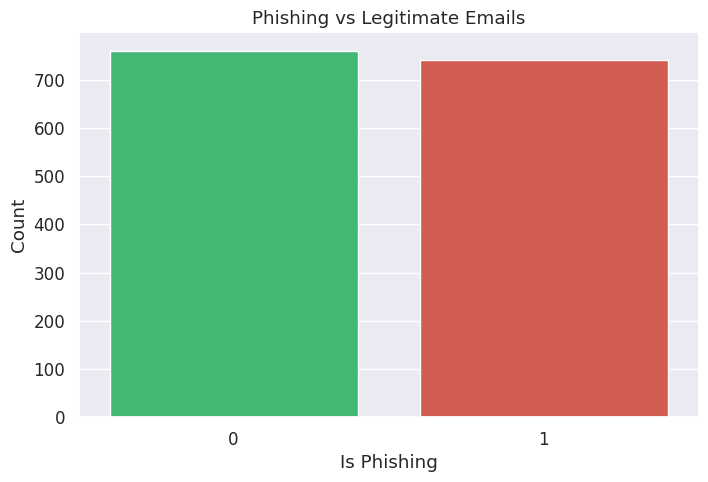

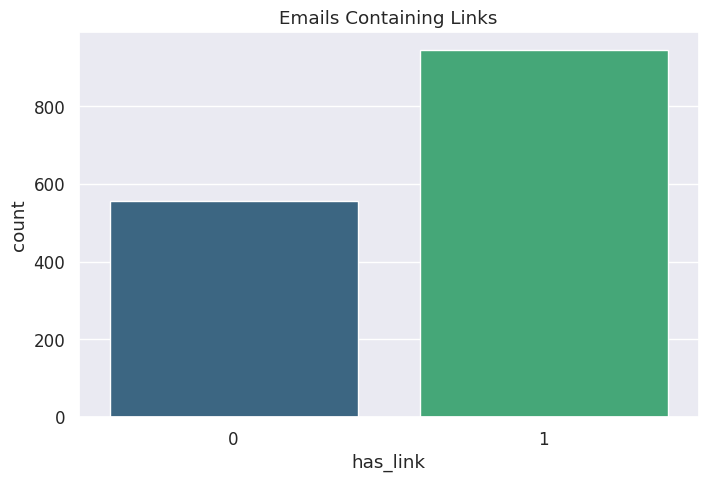

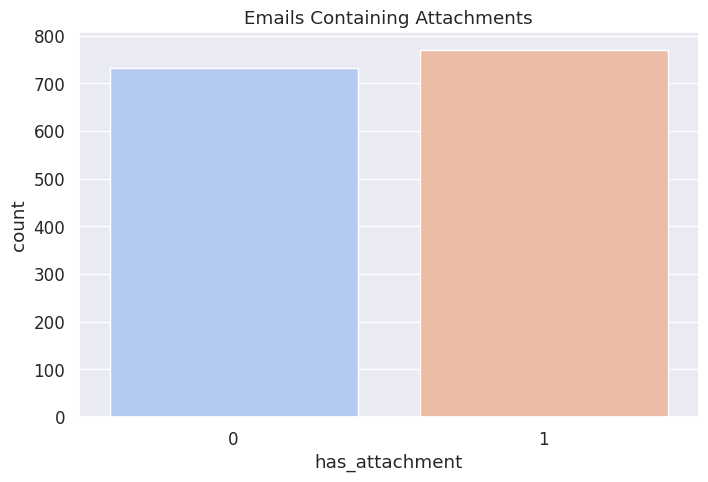

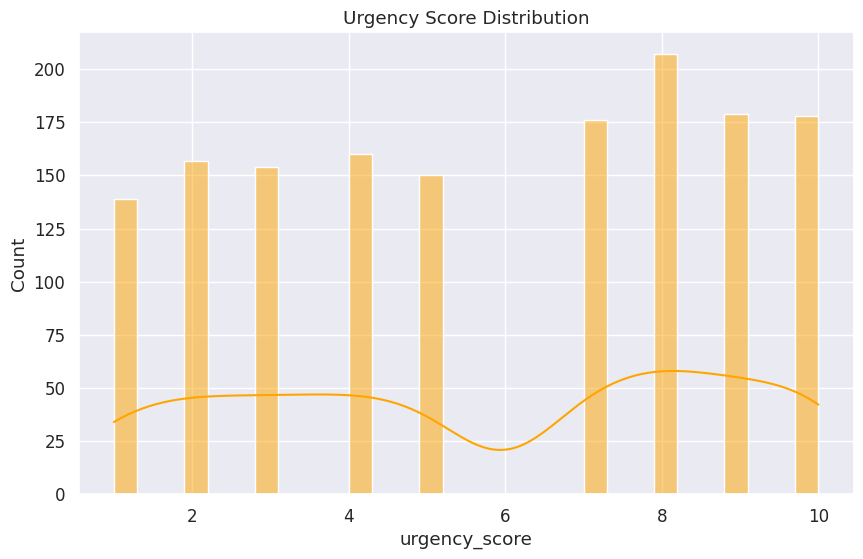

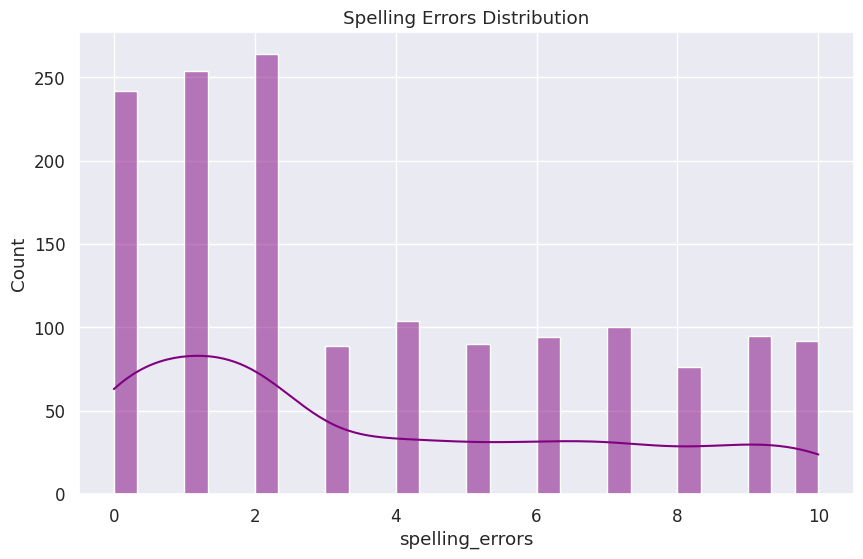

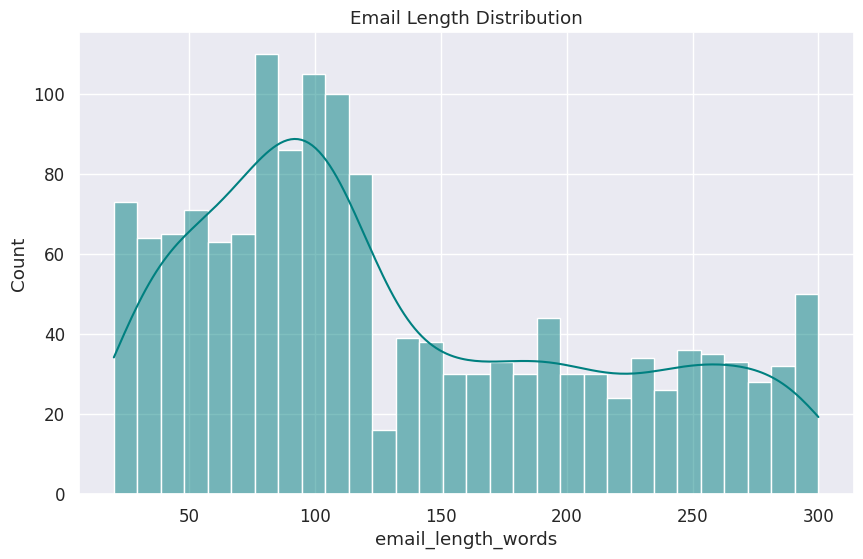

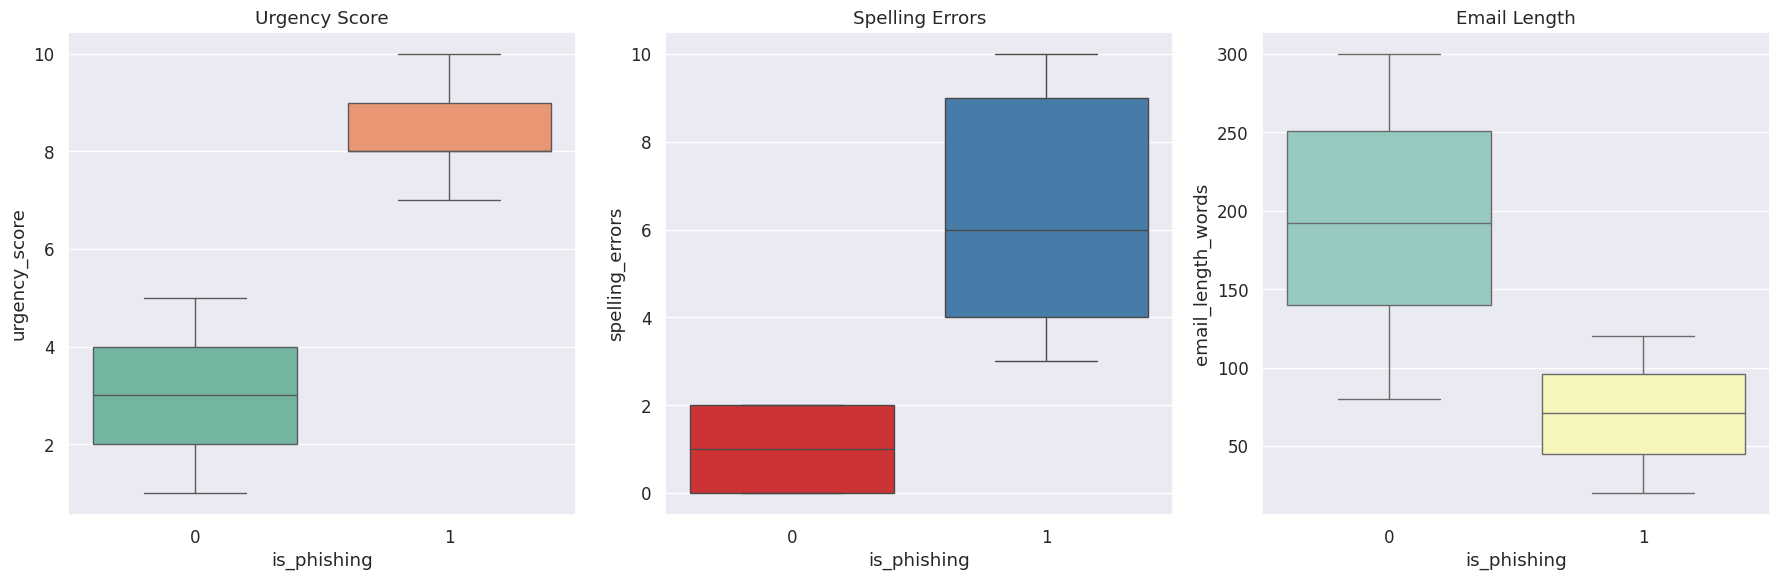

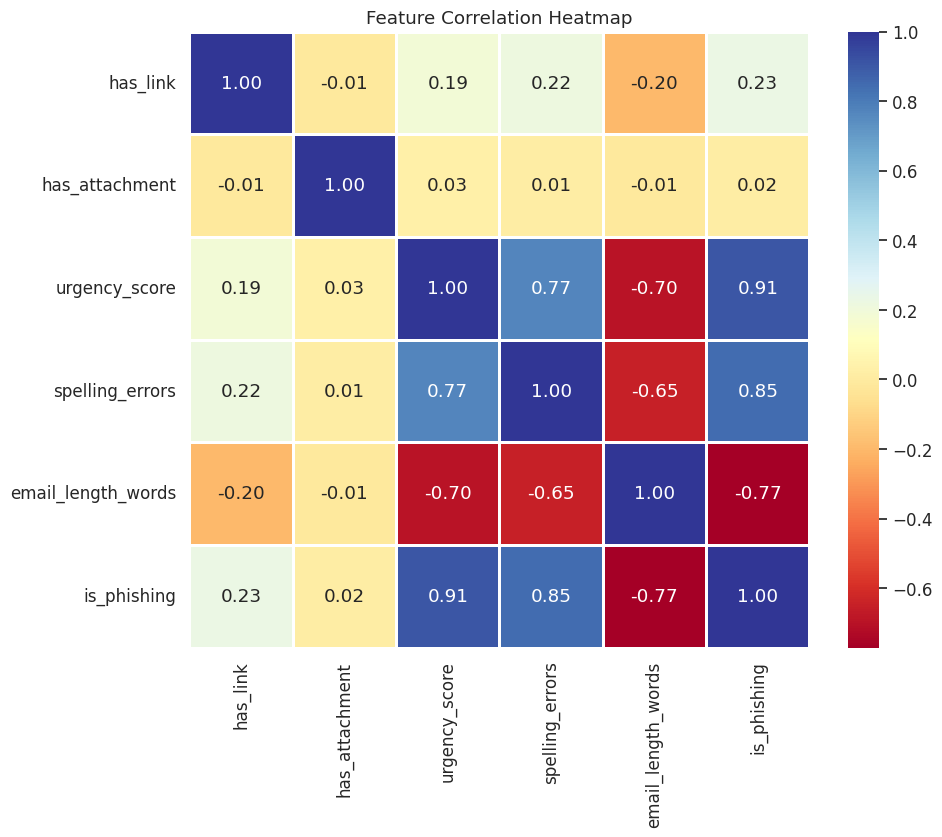

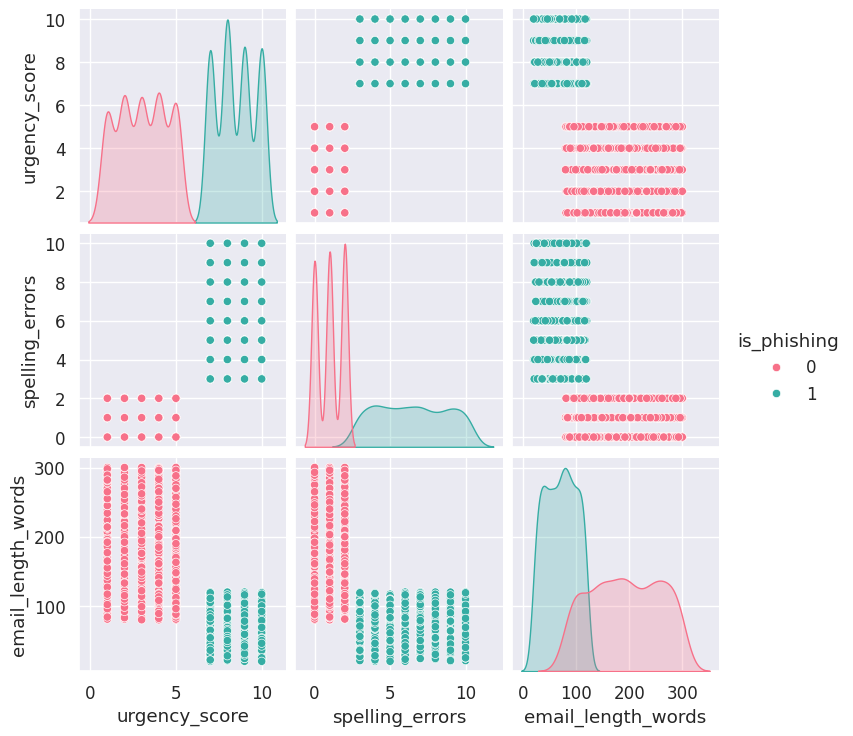

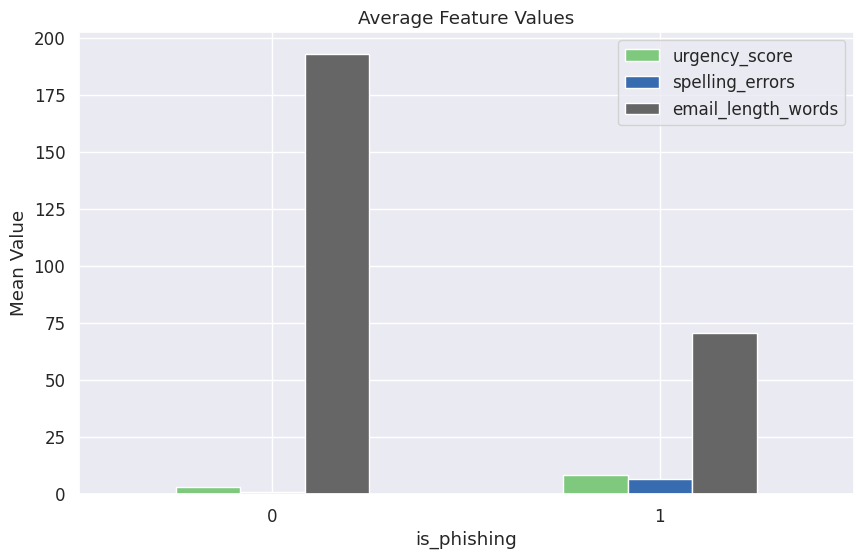

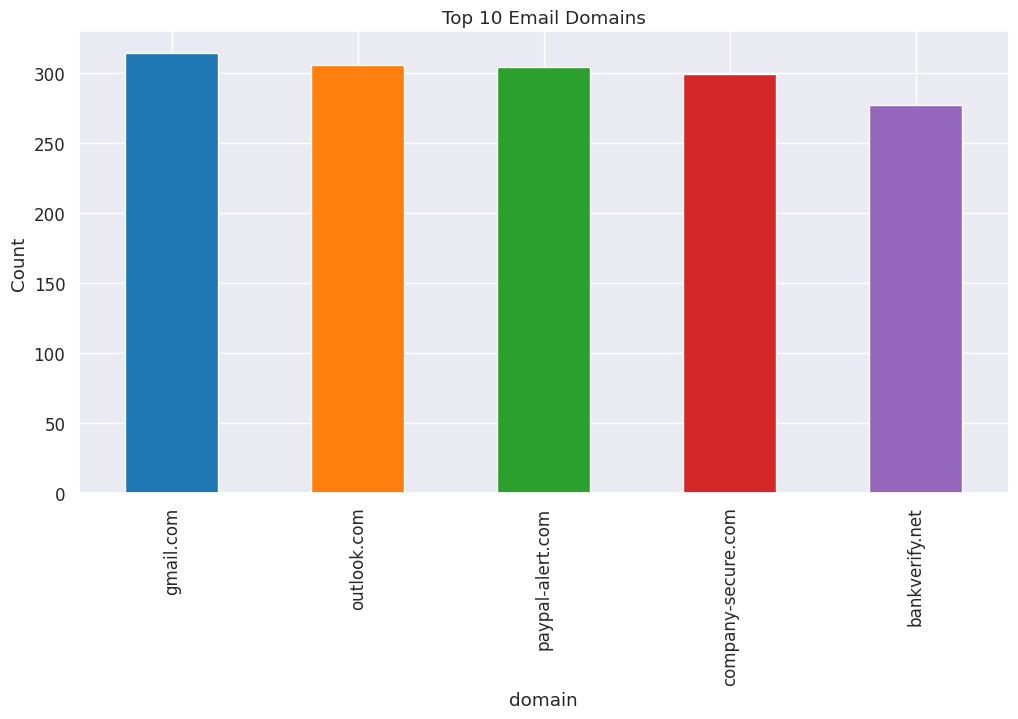

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better Style
plt.style.use('ggplot')
sns.set(font_scale=1.1)

# Dataset Overview
print(df.info())
print(df.describe())

# ==========================================
# 1. Target Variable Distribution
# ==========================================

plt.figure(figsize=(8,5))
sns.countplot(
    x='is_phishing',
    data=df,
    palette=['#2ECC71', '#E74C3C']
)
plt.title('Phishing vs Legitimate Emails')
plt.xlabel('Is Phishing')
plt.ylabel('Count')
plt.show()

# ==========================================
# 2. Has Link Distribution
# ==========================================

plt.figure(figsize=(8,5))
sns.countplot(
    x='has_link',
    data=df,
    palette='viridis'
)
plt.title('Emails Containing Links')
plt.show()

# ==========================================
# 3. Has Attachment Distribution
# ==========================================

plt.figure(figsize=(8,5))
sns.countplot(
    x='has_attachment',
    data=df,
    palette='coolwarm'
)
plt.title('Emails Containing Attachments')
plt.show()

# ==========================================
# 4. Urgency Score Distribution
# ==========================================

plt.figure(figsize=(10,6))
sns.histplot(
    df['urgency_score'],
    bins=30,
    kde=True,
    color='orange'
)
plt.title('Urgency Score Distribution')
plt.show()

# ==========================================
# 5. Spelling Errors Distribution
# ==========================================

plt.figure(figsize=(10,6))
sns.histplot(
    df['spelling_errors'],
    bins=30,
    kde=True,
    color='purple'
)
plt.title('Spelling Errors Distribution')
plt.show()

# ==========================================
# 6. Email Length Distribution
# ==========================================

plt.figure(figsize=(10,6))
sns.histplot(
    df['email_length_words'],
    bins=30,
    kde=True,
    color='teal'
)
plt.title('Email Length Distribution')
plt.show()

# ==========================================
# 7. Boxplots vs Target
# ==========================================

fig, axes = plt.subplots(1,3, figsize=(18,6))

sns.boxplot(
    x='is_phishing',
    y='urgency_score',
    data=df,
    palette='Set2',
    ax=axes[0]
)

sns.boxplot(
    x='is_phishing',
    y='spelling_errors',
    data=df,
    palette='Set1',
    ax=axes[1]
)

sns.boxplot(
    x='is_phishing',
    y='email_length_words',
    data=df,
    palette='Set3',
    ax=axes[2]
)

axes[0].set_title('Urgency Score')
axes[1].set_title('Spelling Errors')
axes[2].set_title('Email Length')

plt.tight_layout()
plt.show()

# ==========================================
# 8. Correlation Heatmap
# ==========================================

numeric_cols = [
    'has_link',
    'has_attachment',
    'urgency_score',
    'spelling_errors',
    'email_length_words',
    'is_phishing'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='RdYlBu',
    linewidths=1,
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')
plt.show()

# ==========================================
# 9. Pairplot
# ==========================================

sns.pairplot(
    df[
        [
            'urgency_score',
            'spelling_errors',
            'email_length_words',
            'is_phishing'
        ]
    ],
    hue='is_phishing',
    palette='husl'
)

plt.show()

# ==========================================
# 10. Average Feature Comparison
# ==========================================

avg_features = df.groupby('is_phishing')[
    [
        'urgency_score',
        'spelling_errors',
        'email_length_words'
    ]
].mean()

avg_features.plot(
    kind='bar',
    figsize=(10,6),
    colormap='Accent'
)

plt.title('Average Feature Values')
plt.ylabel('Mean Value')
plt.xticks(rotation=0)
plt.show()

# ==========================================
# 11. Sender Domain Analysis
# ==========================================

df['domain'] = df['sender_email'].str.split('@').str[-1]

top_domains = df['domain'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_domains.plot(
    kind='bar',
    color=sns.color_palette('tab10')
)

plt.title('Top 10 Email Domains')
plt.ylabel('Count')
plt.show()

## Features Engineering

DATASET INFORMATION
   email_id                      sender_email                      subject  \
0         1   harrisonsandra@paypal-alert.com             Meeting Reminder   
1         2        randyharris@bankverify.net  Urgent Account Verification   
2         3                adam13@outlook.com     Suspicious Login Attempt   
3         4  kennethfisher@company-secure.com     Suspicious Login Attempt   
4         5        wsandoval@paypal-alert.com    Your Password Will Expire   

   has_link  has_attachment  urgency_score  spelling_errors  \
0         0               1              2                0   
1         1               1              9                7   
2         1               1              8               10   
3         0               1              9                8   
4         1               0              7                4   

   email_length_words  is_phishing              domain  
0                 227            0    paypal-alert.com  
1                 

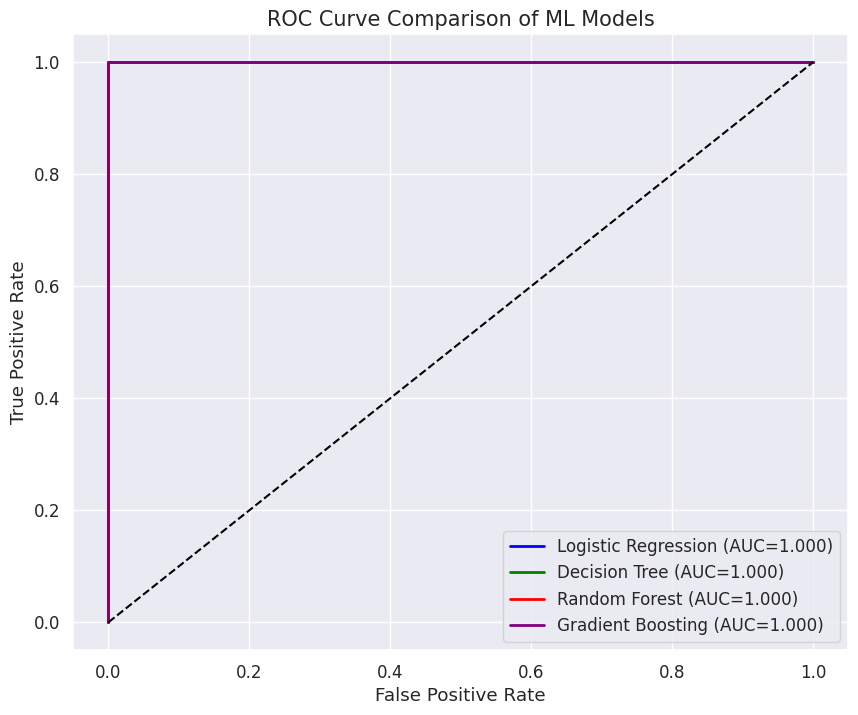



MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression       1.0        1.0     1.0       1.0      1.0
1        Decision Tree       1.0        1.0     1.0       1.0      1.0
2        Random Forest       1.0        1.0     1.0       1.0      1.0
3    Gradient Boosting       1.0        1.0     1.0       1.0      1.0


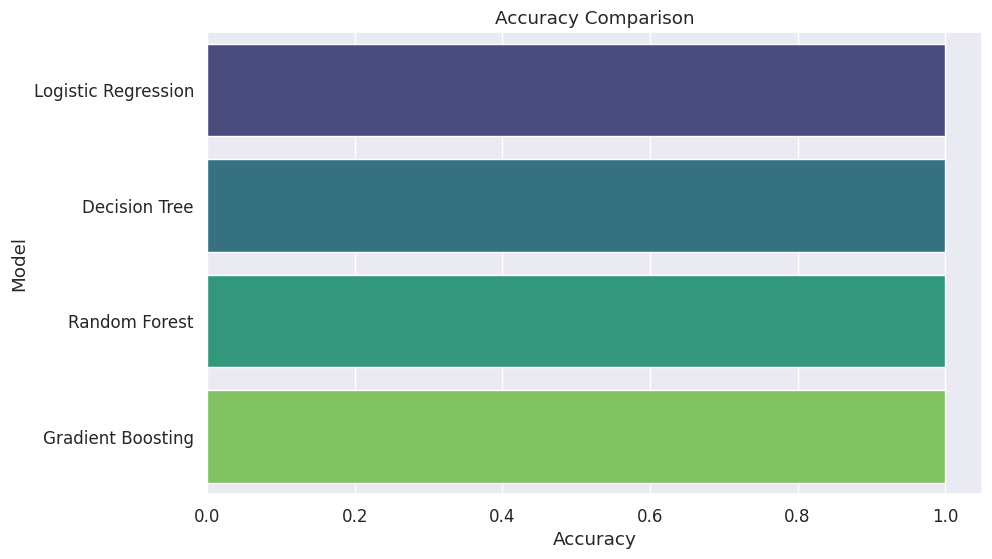



BEST MODEL
Best Model : Logistic Regression
Best ROC AUC : 1.0


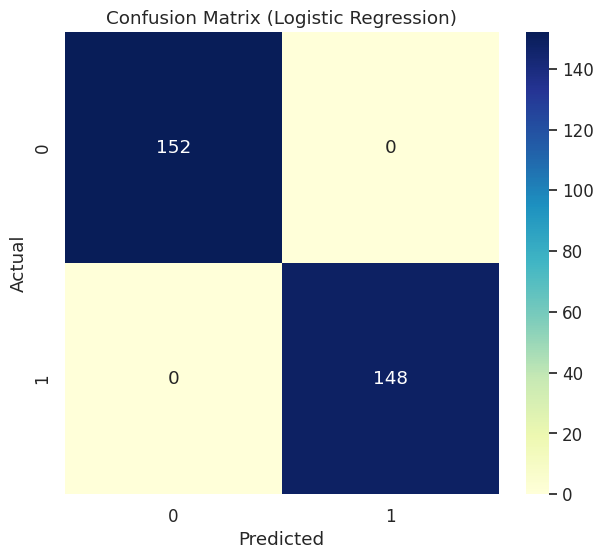



PIPELINE COMPLETED SUCCESSFULLY


In [10]:
# ==========================================================
# PHISHING EMAIL DETECTION - COMPLETE ML PIPELINE
# No Data Leakage | Train-Test Split | Encoding | Multiple ML Models
# Accuracy | Precision | Recall | F1 | ROC Curve | Feature Importance
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# ==========================================================
# DATA PREPARATION
# ==========================================================

print("="*60)
print("DATASET INFORMATION")
print("="*60)

print(df.head())
print(df.info())

# Remove ID column (not useful for prediction)
if 'email_id' in df.columns:
    df = df.drop('email_id', axis=1)

# Features and Target
X = df.drop('is_phishing', axis=1)
y = df['is_phishing']

# ==========================================================
# TRAIN TEST SPLIT (BEFORE ENCODING)
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

# ==========================================================
# FEATURE TYPES
# ==========================================================

categorical_features = [
    'sender_email',
    'subject'
]

numerical_features = [
    'has_link',
    'has_attachment',
    'urgency_score',
    'spelling_errors',
    'email_length_words'
]

# Keep only existing columns
categorical_features = [
    col for col in categorical_features
    if col in X.columns
]

numerical_features = [
    col for col in numerical_features
    if col in X.columns
]

# ==========================================================
# PREPROCESSOR
# ==========================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            'num',
            SimpleImputer(strategy='median'),
            numerical_features
        ),

        (
            'cat',
            Pipeline([
                ('imputer',
                 SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        )
    ]
)

# ==========================================================
# MACHINE LEARNING MODELS
# ==========================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}

# ==========================================================
# TRAINING & EVALUATION
# ==========================================================

results = []

best_auc = 0
best_model_name = ""
best_pipeline = None

plt.figure(figsize=(10,8))

colors = ['blue', 'green', 'red', 'purple']

for (name, model), color in zip(models.items(), colors):

    print("\n")
    print("="*70)
    print(name)
    print("="*70)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Probability
    y_prob = pipeline.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ])

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {auc_score:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(
        y_test,
        y_pred
    ))

    # ROC CURVE
    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f"{name} (AUC={auc_score:.3f})"
    )

    # Best Model
    if auc_score > best_auc:
        best_auc = auc_score
        best_model_name = name
        best_pipeline = pipeline

# ==========================================================
# ROC CURVE COMPARISON
# ==========================================================

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

plt.title(
    "ROC Curve Comparison of ML Models",
    fontsize=15
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()
plt.grid(True)

plt.show()

# ==========================================================
# RESULTS TABLE
# ==========================================================

results_df = pd.DataFrame(

    results,

    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC AUC'
    ]
)

results_df = results_df.sort_values(
    by='ROC AUC',
    ascending=False
)

print("\n")
print("="*70)
print("MODEL COMPARISON")
print("="*70)

print(results_df)

# ==========================================================
# ACCURACY COMPARISON
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='Accuracy',
    y='Model',
    hue='Model',
    palette='viridis',
    legend=False
)

plt.title(
    "Accuracy Comparison"
)

plt.show()

# ==========================================================
# BEST MODEL
# ==========================================================

print("\n")
print("="*70)
print("BEST MODEL")
print("="*70)

print("Best Model :", best_model_name)
print("Best ROC AUC :", round(best_auc,4))

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

y_pred_best = best_pipeline.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title(
    f'Confusion Matrix ({best_model_name})'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# (ONLY FOR RANDOM FOREST)
# ==========================================================

if best_model_name == "Random Forest":

    feature_names = best_pipeline.named_steps[
        'preprocessor'
    ].get_feature_names_out()

    importances = best_pipeline.named_steps[
        'model'
    ].feature_importances_

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    importance_df = importance_df.sort_values(
        by='Importance',
        ascending=False
    )

    print("\nTop 20 Important Features:\n")
    print(importance_df.head(20))

    plt.figure(figsize=(12,8))

    sns.barplot(
        data=importance_df.head(20),
        x='Importance',
        y='Feature',
        palette='magma'
    )

    plt.title(
        'Top 20 Feature Importances'
    )

    plt.show()

print("\n")
print("="*70)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("="*70)

## Thanks...........Please upvotes